<style>
:root { --navy:#0f172a; --blue:#2563eb; --sky:#e0f2fe; --mint:#dcfce7; --amber:#fef3c7; --slate:#475569; }
.hero { padding:28px 32px; border-radius:18px; color:white; background:linear-gradient(135deg,#0f172a 0%,#1d4ed8 62%,#38bdf8 100%); box-shadow:0 10px 28px rgba(37,99,235,.22); margin-bottom:18px; }
.hero h1 { margin:0 0 8px 0; font-size:34px; }
.hero p { margin:5px 0; color:#e0f2fe; }
.badge { display:inline-block; padding:5px 10px; margin:8px 6px 0 0; border-radius:999px; background:rgba(255,255,255,.16); font-size:13px; font-weight:600; }
.purpose { padding:14px 18px; border-left:5px solid var(--blue); background:#eff6ff; border-radius:8px; margin:12px 0; }
.insight { padding:14px 18px; border-left:5px solid #16a34a; background:var(--mint); border-radius:8px; margin:12px 0; }
.method { padding:12px 16px; border-left:5px solid #d97706; background:var(--amber); border-radius:8px; margin:12px 0; }
h2 { color:var(--navy); border-bottom:2px solid #bfdbfe; padding-bottom:7px; margin-top:34px !important; }
h3 { color:#1d4ed8; }
</style>

<div class="hero">
<h1>Task 1 · PostgreSQL Business Analysis</h1>
<p>Decision-oriented analysis of the GitHub project's prepared Online Retail II dataset</p>
<span class="badge">PostgreSQL</span><span class="badge">1,033,036 line items</span><span class="badge">4 business queries</span><span class="badge">Performance tested</span>
</div>

| Dataset | Database | Analytical scope |
|:--|:--|:--|
| UCI Online Retail II | `online_retail_github` on PostgreSQL | Completed sales with positive quantity and price |

### Analysis roadmap

1. Geographic revenue performance  
2. Leading products within major markets  
3. Customers outperforming their local benchmark  
4. Monthly revenue, growth, and cumulative performance  
5. Index optimization with `EXPLAIN ANALYSE`

## ① Database connection

Postgres.app is running locally on port 5433. The helper function below sends a SQL statement to PostgreSQL and returns the result as a pandas table.

In [1]:
import psycopg2
import pandas as pd
from IPython.display import display

connection = psycopg2.connect(
    host="localhost",
    port=5433,
    dbname="online_retail_github",
    user="mahnoorzaheer"
)

def run_query(sql):
    with connection.cursor() as cursor:
        cursor.execute(sql)
        columns = [column.name for column in cursor.description]
        return pd.DataFrame(cursor.fetchall(), columns=columns)

print("Connected successfully to PostgreSQL.")

Connected successfully to PostgreSQL.


## ② Data verification

Before analysing the data, verify that all four normalized tables contain the expected number of rows.

In [2]:
verification_sql = """
SELECT 'customers' AS table_name, COUNT(*) AS row_count FROM customers
UNION ALL
SELECT 'products', COUNT(*) FROM products
UNION ALL
SELECT 'invoices', COUNT(*) FROM invoices
UNION ALL
SELECT 'invoice_items', COUNT(*) FROM invoice_items;
"""
verification_result = run_query(verification_sql)
display(
    verification_result.style
    .hide(axis='index')
    .format({'row_count': '{:,.0f}'})
    .background_gradient(subset=['row_count'], cmap='Blues')
    .set_caption('Verified PostgreSQL Table Counts')
)

table_name,row_count
customers,"5,942"
products,"5,305"
invoices,"53,628"
invoice_items,"1,033,036"


## ③ Query 1 · Geographic revenue leaders

<div class="purpose"><b>Business question</b><br>Which countries generate the most completed-sales revenue?</div>

Identify the strongest geographic markets by revenue while also showing their customer and invoice volumes. This can help management prioritize regional marketing, stock allocation, and customer-retention activity.

<div class="method"><b>SQL techniques</b> · Three-table JOIN · filtering · aggregation · GROUP BY · distinct counts · ordering</div>

In [3]:
query_1 = """
SELECT
    c.country,
    COUNT(DISTINCT c.customer_id) AS unique_customers,
    COUNT(DISTINCT i.invoice_no) AS completed_invoices,
    ROUND(SUM(ii.quantity * ii.unit_price), 2) AS total_revenue
FROM customers AS c
JOIN invoices AS i
    ON c.customer_id = i.customer_id
JOIN invoice_items AS ii
    ON i.invoice_no = ii.invoice_no
WHERE i.is_cancelled = FALSE
  AND ii.quantity > 0
  AND ii.unit_price > 0
GROUP BY c.country
ORDER BY total_revenue DESC
LIMIT 10;
"""
query_1_result = run_query(query_1)
display(
    query_1_result.style
    .hide(axis='index')
    .format({
        'unique_customers': '{:,.0f}',
        'completed_invoices': '{:,.0f}',
        'total_revenue': '£{:,.2f}'
    })
    .background_gradient(subset=['total_revenue'], cmap='Blues')
    .set_caption('Top 10 Countries by Completed-Sales Revenue')
)

country,unique_customers,completed_invoices,total_revenue
United Kingdom,"5,556","37,166","£17,798,115.48"
EIRE,21,632,"£646,190.10"
Netherlands,15,217,"£550,663.51"
Germany,60,623,"£391,809.50"
France,56,524,"£274,949.44"
Australia,13,85,"£163,818.51"
Sweden,12,70,"£82,652.66"
Spain,23,100,"£77,680.98"
Denmark,7,44,"£67,517.30"
Switzerland,9,46,"£58,963.10"


### 💡 Interpretation

<div class="insight">The United Kingdom is the dominant market, producing <b>£17.80 million</b> from 37,166 completed invoices and 5,556 identified customers. EIRE is a distant second at £646,190.10, while the Netherlands generates £550,663.51 from only 15 customers, suggesting a small but unusually high-value customer base that may deserve focused account management.</div>

## ④ Query 2 · Product leaders by market

<div class="purpose"><b>Business question</b><br>Which products generate the most revenue in the five largest markets?</div>

Show each major market's three highest-revenue products so that product selection and promotions can be adapted by country. The analysis first identifies the five largest markets rather than assuming that every country should receive equal attention.

<div class="method"><b>SQL techniques</b> · multiple CTEs · four-table joins · aggregation · DENSE_RANK() window function</div>

In [4]:
query_2 = """
WITH market_revenue AS (
    SELECT
        c.country,
        SUM(ii.quantity * ii.unit_price) AS country_revenue
    FROM customers AS c
    JOIN invoices AS i ON c.customer_id = i.customer_id
    JOIN invoice_items AS ii ON i.invoice_no = ii.invoice_no
    WHERE i.is_cancelled = FALSE
      AND ii.quantity > 0
      AND ii.unit_price > 0
    GROUP BY c.country
),
top_markets AS (
    SELECT country
    FROM market_revenue
    ORDER BY country_revenue DESC
    LIMIT 5
),
product_revenue AS (
    SELECT
        c.country,
        p.stock_code,
        p.description,
        SUM(ii.quantity) AS units_sold,
        SUM(ii.quantity * ii.unit_price) AS product_revenue
    FROM customers AS c
    JOIN invoices AS i ON c.customer_id = i.customer_id
    JOIN invoice_items AS ii ON i.invoice_no = ii.invoice_no
    JOIN products AS p ON ii.stock_code = p.stock_code
    JOIN top_markets AS tm ON c.country = tm.country
    WHERE i.is_cancelled = FALSE
      AND ii.quantity > 0
      AND ii.unit_price > 0
    GROUP BY c.country, p.stock_code, p.description
),
ranked_products AS (
    SELECT
        country, stock_code, description, units_sold, product_revenue,
        DENSE_RANK() OVER (
            PARTITION BY country
            ORDER BY product_revenue DESC
        ) AS product_rank
    FROM product_revenue
)
SELECT
    country, product_rank, stock_code, description, units_sold,
    ROUND(product_revenue, 2) AS product_revenue
FROM ranked_products
WHERE product_rank <= 3
ORDER BY country, product_rank, stock_code;
"""
query_2_result = run_query(query_2)
display(
    query_2_result.style
    .hide(axis='index')
    .format({
        'product_rank': '{:.0f}',
        'units_sold': '{:,.0f}',
        'product_revenue': '£{:,.2f}'
    })
    .background_gradient(subset=['product_revenue'], cmap='YlGnBu')
    .set_caption('Top Three Products in Each of the Five Largest Markets')
)

country,product_rank,stock_code,description,units_sold,product_revenue
EIRE,1,M,Manual,27,"£22,756.26"
EIRE,2,22423,REGENCY CAKESTAND 3 TIER,"1,288","£14,751.60"
EIRE,3,C2,CARRIAGE,185,"£9,225.00"
France,1,POST,POSTAGE,"1,080","£20,368.00"
France,2,23084,RABBIT NIGHT LIGHT,"3,393","£6,137.91"
France,3,21731,RED TOADSTOOL LED NIGHT LIGHT,"2,248","£3,716.60"
Germany,1,POST,POSTAGE,"1,629","£30,984.20"
Germany,2,22423,REGENCY CAKESTAND 3 TIER,"1,181","£14,081.61"
Germany,3,22326,"ROUND SNACK BOXES ,SET4, WOODLAND","2,315","£6,608.39"
Netherlands,1,22326,"ROUND SNACK BOXES ,SET4, WOODLAND","5,211","£13,320.89"


### 💡 Interpretation

<div class="insight">The results show that product demand differs substantially across the five largest markets, supporting country-specific merchandising rather than one universal product strategy. <b>DOTCOM POSTAGE</b> ranks first in the United Kingdom at £300,833.82, while <b>ROUND SNACK BOXES ,SET4, WOODLAND</b> leads the Netherlands at £13,320.89; postage and manual-adjustment codes should be separated from physical merchandise in operational product decisions.</div>

## ⑤ Query 3 · High-value customer outliers

<div class="purpose"><b>Business question</b><br>Which customers spend more than the average customer in their country?</div>

Identify unusually valuable customers relative to their local market, rather than comparing every customer with one global benchmark. These customers are strong candidates for retention offers, account management, and loyalty programmes.

<div class="method"><b>SQL techniques</b> · two CTEs · three-table joins · aggregation · local-average benchmark</div>

In [5]:
query_3 = """
WITH customer_spending AS (
    SELECT
        c.customer_id,
        c.country,
        COUNT(DISTINCT i.invoice_no) AS completed_invoices,
        SUM(ii.quantity * ii.unit_price) AS customer_revenue
    FROM customers AS c
    JOIN invoices AS i ON c.customer_id = i.customer_id
    JOIN invoice_items AS ii ON i.invoice_no = ii.invoice_no
    WHERE i.is_cancelled = FALSE
      AND ii.quantity > 0
      AND ii.unit_price > 0
    GROUP BY c.customer_id, c.country
),
country_benchmarks AS (
    SELECT
        country,
        AVG(customer_revenue) AS average_customer_revenue
    FROM customer_spending
    GROUP BY country
)
SELECT
    cs.customer_id,
    cs.country,
    cs.completed_invoices,
    ROUND(cs.customer_revenue, 2) AS customer_revenue,
    ROUND(cb.average_customer_revenue, 2) AS country_average,
    ROUND(cs.customer_revenue - cb.average_customer_revenue, 2)
        AS above_average_by
FROM customer_spending AS cs
JOIN country_benchmarks AS cb ON cs.country = cb.country
WHERE cs.customer_revenue > cb.average_customer_revenue
ORDER BY above_average_by DESC
LIMIT 15;
"""
query_3_result = run_query(query_3)
display(
    query_3_result.style
    .hide(axis='index')
    .format({
        'customer_id': '{:.0f}',
        'completed_invoices': '{:,.0f}',
        'customer_revenue': '£{:,.2f}',
        'country_average': '£{:,.2f}',
        'above_average_by': '£{:,.2f}'
    })
    .background_gradient(subset=['above_average_by'], cmap='Greens')
    .set_caption('Customers with the Largest Positive Gap Above Their Country Average')
)

customer_id,country,completed_invoices,customer_revenue,country_average,above_average_by
18102,United Kingdom,146,"£587,301.04","£3,203.40","£584,097.64"
14646,Netherlands,154,"£530,060.88","£36,710.90","£493,349.98"
14156,EIRE,157,"£315,983.47","£30,770.96","£285,212.51"
14911,EIRE,399,"£291,758.91","£30,770.96","£260,987.95"
17450,United Kingdom,52,"£244,936.89","£3,203.40","£241,733.49"
13694,United Kingdom,143,"£195,640.69","£3,203.40","£192,437.29"
16446,United Kingdom,6,"£173,239.47","£3,203.40","£170,036.07"
17511,United Kingdom,60,"£172,132.87","£3,203.40","£168,929.47"
16684,United Kingdom,57,"£147,178.37","£3,203.40","£143,974.97"
12415,Australia,28,"£144,458.37","£12,601.42","£131,856.95"


### 💡 Interpretation

<div class="insight">Customer <b>18102</b> is the largest positive outlier, generating £587,301.04 compared with a United Kingdom customer average of £3,203.40. Customer <b>14646</b> is similarly important in the Netherlands, exceeding the local average by £493,349.98; the large gaps show that a small number of high-value accounts contribute disproportionately to revenue.</div>

## ⑥ Query 4 · Monthly momentum and seasonality

<div class="purpose"><b>Business question</b><br>How does completed-sales revenue change each month?</div>

Measure revenue trends, monthly growth, and cumulative performance to support seasonal planning and realistic sales targets. Because this is a company-level revenue analysis, valid completed invoices without a customer ID are included.

<div class="method"><b>SQL techniques</b> · CTEs · date aggregation · LAG() · running SUM() · NULLIF()</div>

In [6]:
query_4 = """
WITH monthly_sales AS (
    SELECT
        DATE_TRUNC('month', i.invoice_date)::date AS revenue_month,
        SUM(ii.quantity * ii.unit_price) AS monthly_revenue
    FROM invoices AS i
    JOIN invoice_items AS ii ON i.invoice_no = ii.invoice_no
    WHERE i.is_cancelled = FALSE
      AND ii.quantity > 0
      AND ii.unit_price > 0
    GROUP BY DATE_TRUNC('month', i.invoice_date)
),
monthly_metrics AS (
    SELECT
        revenue_month,
        monthly_revenue,
        LAG(monthly_revenue) OVER (ORDER BY revenue_month)
            AS previous_month_revenue,
        SUM(monthly_revenue) OVER (
            ORDER BY revenue_month
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS running_revenue
    FROM monthly_sales
)
SELECT
    revenue_month,
    ROUND(monthly_revenue, 2) AS monthly_revenue,
    ROUND(previous_month_revenue, 2) AS previous_month_revenue,
    ROUND(
        100.0 * (monthly_revenue - previous_month_revenue)
        / NULLIF(previous_month_revenue, 0),
        2
    ) AS month_on_month_growth_pct,
    ROUND(running_revenue, 2) AS running_revenue
FROM monthly_metrics
ORDER BY revenue_month;
"""
query_4_result = run_query(query_4)
display(
    query_4_result.style
    .hide(axis='index')
    .format({
        'monthly_revenue': '£{:,.2f}',
        'previous_month_revenue': '£{:,.2f}',
        'month_on_month_growth_pct': '{:+.2f}%',
        'running_revenue': '£{:,.2f}'
    }, na_rep='—')
    .background_gradient(subset=['monthly_revenue'], cmap='Blues')
    .set_caption('Monthly Revenue, Growth, and Cumulative Performance')
)

revenue_month,monthly_revenue,previous_month_revenue,month_on_month_growth_pct,running_revenue
2009-12-01,"£822,483.95",—,—,"£822,483.95"
2010-01-01,"£651,155.11","£822,483.95",-20.83%,"£1,473,639.06"
2010-02-01,"£551,504.72","£651,155.11",-15.30%,"£2,025,143.78"
2010-03-01,"£830,915.26","£551,504.72",+50.66%,"£2,856,059.04"
2010-04-01,"£678,875.25","£830,915.26",-18.30%,"£3,534,934.29"
2010-05-01,"£657,705.50","£678,875.25",-3.12%,"£4,192,639.79"
2010-06-01,"£749,537.31","£657,705.50",+13.96%,"£4,942,177.10"
2010-07-01,"£648,810.27","£749,537.31",-13.44%,"£5,590,987.37"
2010-08-01,"£695,251.91","£648,810.27",+7.16%,"£6,286,239.28"
2010-09-01,"£921,696.99","£695,251.91",+32.57%,"£7,207,936.27"


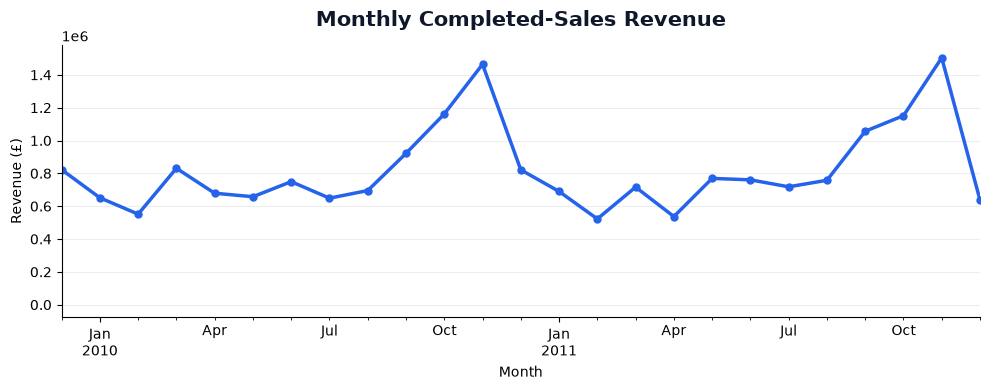

In [7]:
chart_data = query_4_result.copy()
chart_data['revenue_month'] = pd.to_datetime(chart_data['revenue_month'])
chart_data['monthly_revenue'] = chart_data['monthly_revenue'].astype(float)
ax = chart_data.plot(
    x='revenue_month', y='monthly_revenue', figsize=(10, 4),
    marker='o', markersize=5, linewidth=2.5, legend=False, color='#2563eb'
)
ax.fill_between(chart_data['revenue_month'], chart_data['monthly_revenue'], color='#93c5fd', alpha=0.28)
ax.set_title('Monthly Completed-Sales Revenue', fontsize=15, fontweight='bold', color='#0f172a', pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.22)
ax.figure.tight_layout();

### 💡 Interpretation

<div class="insight">Revenue shows a repeating seasonal pattern: it rises strongly during September–November and peaks at <b>£1.50 million</b> in November 2011. The running total reaches £20.48 million by 9 December 2011; the apparent 57.59% December decline should not be treated as a full-month deterioration because the dataset ends on 9 December, making that final month incomplete.</div>

## ⑦ Performance optimization · Indexing product lookups

**Test question:** How does monthly performance change for stock code `22423`, the leading UK product identified in Query 2?

The same query is measured before and after creating an index on `invoice_items(stock_code)`. The code deliberately removes only this demonstration index first, guaranteeing a genuine unindexed baseline whenever the notebook is rerun.

In [8]:
performance_query = """
SELECT
    DATE_TRUNC('month', i.invoice_date)::date AS revenue_month,
    SUM(ii.quantity) AS units_sold,
    ROUND(SUM(ii.quantity * ii.unit_price), 2) AS product_revenue
FROM invoice_items AS ii
JOIN invoices AS i ON ii.invoice_no = i.invoice_no
WHERE ii.stock_code = '22423'
  AND i.is_cancelled = FALSE
  AND ii.quantity > 0
  AND ii.unit_price > 0
GROUP BY DATE_TRUNC('month', i.invoice_date)
ORDER BY revenue_month;
"""
display(run_query(performance_query))

,revenue_month,units_sold,product_revenue
0,2010-03-01,749,9865.11
1,2010-04-01,1167,14383.09
2,2010-05-01,540,6771.88
3,2010-06-01,1355,16577.53
4,2010-07-01,1544,18865.88
5,2010-08-01,1045,13258.53
6,2010-09-01,2061,24771.17
7,2010-10-01,1965,23904.01
8,2010-11-01,2201,28036.58
9,2010-12-01,2077,27694.76


In [9]:
import re

def explain_analyse(sql):
    with connection.cursor() as cursor:
        cursor.execute('EXPLAIN (ANALYSE, BUFFERS) ' + sql)
        return '\n'.join(row[0] for row in cursor.fetchall())

# Remove only the assignment demonstration index to obtain the baseline.
with connection.cursor() as cursor:
    cursor.execute('DROP INDEX IF EXISTS idx_invoice_items_stock_code;')
connection.commit()

before_plan = explain_analyse(performance_query)
print('BEFORE INDEX\n')
print(before_plan)

BEFORE INDEX

Sort  (cost=20235.66..20242.60 rows=2775 width=52) (actual time=34.054..34.451 rows=22.00 loops=1)
  Sort Key: (((date_trunc('month'::text, i.invoice_date)))::date)
  Sort Method: quicksort  Memory: 26kB
  Buffers: shared hit=21514
  ->  GroupAggregate  (cost=19656.64..20076.95 rows=2775 width=52) (actual time=33.395..34.447 rows=22.00 loops=1)
        Group Key: (date_trunc('month'::text, i.invoice_date))
        Buffers: shared hit=21514
        ->  Gather Merge  (cost=19656.64..19979.83 rows=2775 width=26) (actual time=33.364..34.032 rows=3950.00 loops=1)
              Workers Planned: 2
              Workers Launched: 2
              Buffers: shared hit=21514
              ->  Sort  (cost=18656.61..18659.50 rows=1156 width=26) (actual time=31.420..31.449 rows=1316.67 loops=3)
                    Sort Key: (date_trunc('month'::text, i.invoice_date))
                    Sort Method: quicksort  Memory: 115kB
                    Buffers: shared hit=21514
                 

In [10]:
with connection.cursor() as cursor:
    cursor.execute(
        'CREATE INDEX idx_invoice_items_stock_code '
        'ON invoice_items(stock_code);'
    )
    cursor.execute('ANALYSE invoice_items;')
connection.commit()

after_plan = explain_analyse(performance_query)
print('AFTER INDEX\n')
print(after_plan)

AFTER INDEX

Sort  (cost=9231.50..9239.35 rows=3140 width=52) (actual time=7.752..7.754 rows=22.00 loops=1)
  Sort Key: (((date_trunc('month'::text, i.invoice_date)))::date)
  Sort Method: quicksort  Memory: 26kB
  Buffers: shared hit=3777 read=7
  ->  HashAggregate  (cost=8978.47..9049.12 rows=3140 width=52) (actual time=7.736..7.749 rows=22.00 loops=1)
        Group Key: date_trunc('month'::text, i.invoice_date)
        Batches: 1  Memory Usage: 97kB
        Buffers: shared hit=3777 read=7
        ->  Hash Join  (cost=1596.19..8939.22 rows=3140 width=26) (actual time=5.284..7.284 rows=3950.00 loops=1)
              Hash Cond: ((ii.invoice_no)::text = (i.invoice_no)::text)
              Buffers: shared hit=3777 read=7
              ->  Bitmap Heap Scan on invoice_items ii  (cost=46.02..7371.45 rows=3713 width=17) (actual time=0.383..1.788 rows=3950.00 loops=1)
                    Recheck Cond: ((stock_code)::text = '22423'::text)
                    Filter: ((quantity > 0) AND (unit_p

In [11]:
def execution_time(plan):
    return float(re.search(r'Execution Time: ([0-9.]+) ms', plan).group(1))

before_ms = execution_time(before_plan)
after_ms = execution_time(after_plan)
comparison = pd.DataFrame({
    'plan': ['Before index', 'After index'],
    'execution_time_ms': [before_ms, after_ms],
    'access_method': [
        'Parallel sequential scan',
        'Bitmap index + bitmap heap scan'
    ]
})
display(
    comparison.style
    .hide(axis='index')
    .format({'execution_time_ms': '{:.3f} ms'})
    .background_gradient(subset=['execution_time_ms'], cmap='RdYlGn_r')
    .set_caption('EXPLAIN ANALYSE Performance Comparison')
)
print(f'Speed-up: {before_ms / after_ms:.2f}x')
print(f'Execution-time reduction: {(1 - after_ms / before_ms) * 100:.1f}%')

plan,execution_time_ms,access_method
Before index,34.476 ms,Parallel sequential scan
After index,7.917 ms,Bitmap index + bitmap heap scan


Speed-up: 4.35x
Execution-time reduction: 77.0%


### ⚡ Performance interpretation

<div class="insight">Before indexing, PostgreSQL used a parallel sequential scan and inspected the entire <b>1,033,036-row</b> `invoice_items` table to locate stock code `22423`. After creating `idx_invoice_items_stock_code`, the plan changed to a bitmap index scan followed by a bitmap heap scan, producing a <b>4.35× speed-up</b> and a <b>77.0% execution-time reduction</b> in the saved run.</div>